In [1]:
from collections import defaultdict
from pathlib import Path

import equinox as eqx
import h5py
import jax
import jax.numpy as jnp
import numpy as np
import xarray as xr
from context_flux_no.metrics import relative_L2_error, relative_L_infty_error
from context_flux_no.training.io import load_model
from einops import rearrange
from more_itertools import one
from tqdm import tqdm


datadir = Path("../../data")
checkpoint_dir = Path("../../checkpoints")

jax.config.update("jax_default_device", jax.devices("gpu")[0])

In [2]:
@eqx.filter_jit
def compute_metrics(model, u, args, context_length=20):
    context, u_data = u[:context_length], u[context_length:]

    u_pred = model.rollout(context, args, num_steps=len(u_data))[0]

    return {
        "l2_onestep": relative_L2_error(u_pred[0], u_data[0]),
        "l_inf_onestep": relative_L_infty_error(u_pred[0], u_data[0]),
        "l2_rollout": relative_L2_error(u_pred, u_data),
        "l_inf_rollout": relative_L_infty_error(u_pred, u_data),
    }


In [3]:
dataset_test = xr.open_dataset(
    datadir
    / "datasets/shallow_water_1d/data/test/shallow_water_1d_test_grf_seed=10.hdf5",
    engine="h5netcdf",
    chunks={},
)
dt = float(dataset_test["t"][1] - dataset_test["t"][0])
dx = float(dataset_test["x"][1] - dataset_test["x"][0])

values = dataset_test["values"].values
segments = np.lib.stride_tricks.sliding_window_view(values, 40, axis=1)
segments = rearrange(segments, "batch t0 c x t -> (batch t0) t c x")
segments.shape

(555024, 40, 2, 100)

In [ ]:
dt = float(dataset_test["t"][1] - dataset_test["t"][0])
dx = float(dataset_test["x"][1] - dataset_test["x"][0])
results_dict = defaultdict(list)
for model_type in ("DPOT", "HyperFluxFNOLocal", "DISCO"):
    for seed in tqdm((0, 10, 20)):
        model_dir = (
            checkpoint_dir
            / "shallow_water_1d"
            / model_type
            / "OneStepLoss"
            / f"seed={seed}"
        )
        model = load_model(one(model_dir.iterdir()))
        model = eqx.nn.inference_mode(model, True)
        results = jax.lax.map(
            eqx.filter_jit(lambda u: compute_metrics(model, u, (dt, dx))),
            segments,
            batch_size=1500,
        )
        print(jax.tree.map(lambda x: x.shape, results))
        results_dict[model_type].append(jax.tree.map(jnp.mean, results))

  0%|          | 0/3 [00:00<?, ?it/s]

E0501 17:36:24.948159 3601184 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


{'l2_onestep': (555024,), 'l2_rollout': (555024,), 'l_inf_onestep': (555024,), 'l_inf_rollout': (555024,)}


 33%|███▎      | 1/3 [04:52<09:45, 292.68s/it]ERROR:asyncio:Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/home/jhko725/.local/share/uv/python/cpython-3.12.11-linux-x86_64-gnu/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x146ba05b14c0> is already entered
ERROR:asyncio:Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/home/jhko725/.local/share/uv/python/cpython-3.12.11-linux-x86_64-gnu/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x146ba05b14c0> is already entered
ERROR:asyncio:Task was destroyed but it is pending!
task: <Task pending name='Task-280' coro=<_async_in_context.<locals>.run_in_context() done, defined at

{'l2_onestep': (555024,), 'l2_rollout': (555024,), 'l_inf_onestep': (555024,), 'l_inf_rollout': (555024,)}


...

{'l2_onestep': (555024,), 'l2_rollout': (555024,), 'l_inf_onestep': (555024,), 'l_inf_rollout': (555024,)}


 67%|██████▋   | 2/3 [1:47:35<53:56, 3236.35s/it]

{'l2_onestep': (555024,), 'l2_rollout': (555024,), 'l_inf_onestep': (555024,), 'l_inf_rollout': (555024,)}


100%|██████████| 3/3 [2:37:41<00:00, 3153.69s/it]

{'l2_onestep': (555024,), 'l2_rollout': (555024,), 'l_inf_onestep': (555024,), 'l_inf_rollout': (555024,)}


In [5]:
import json


with open("../../data/analysis/shallow_water_indistribution.json", "w") as f:
    json.dump(jax.tree.map(lambda x: float(x), results_dict), f)

In [6]:
for model_name, res in results_dict.items():
    res_ = jax.tree.transpose(jax.tree.structure(["*"] * 3), None, res)
    print(
        model_name,
        jax.tree.map(
            lambda list_: {
                "mean": jnp.mean(jnp.asarray(list_)),
                "std": jnp.std(jnp.asarray(list_)),
            },
            res_,
            is_leaf=lambda x: isinstance(x, list),
        ),
    )

DPOT {'l2_onestep': {'mean': Array(0.00849266, dtype=float32), 'std': Array(0.00040023, dtype=float32)}, 'l2_rollout': {'mean': Array(0.10509228, dtype=float32), 'std': Array(0.00366279, dtype=float32)}, 'l_inf_onestep': {'mean': Array(0.02880038, dtype=float32), 'std': Array(0.00159386, dtype=float32)}, 'l_inf_rollout': {'mean': Array(0.46339116, dtype=float32), 'std': Array(0.01000239, dtype=float32)}}
HyperFluxFNOLocal {'l2_onestep': {'mean': Array(0.00627432, dtype=float32), 'std': Array(2.7117803e-05, dtype=float32)}, 'l2_rollout': {'mean': Array(0.07553041, dtype=float32), 'std': Array(0.00125867, dtype=float32)}, 'l_inf_onestep': {'mean': Array(0.02293285, dtype=float32), 'std': Array(0.00038121, dtype=float32)}, 'l_inf_rollout': {'mean': Array(0.39806098, dtype=float32), 'std': Array(0.00420777, dtype=float32)}}
DISCO {'l2_onestep': {'mean': Array(0.0141818, dtype=float32), 'std': Array(0.00062773, dtype=float32)}, 'l2_rollout': {'mean': Array(0.11117677, dtype=float32), 'std':

## Long term

In [4]:
@eqx.filter_jit
def metrics_long_rollout(model, u, args, context_length=20):
    context, u_data = u[:context_length], u[context_length:]
    u_pred = model.rollout(context, args, num_steps=len(u_data))[0]
    l2 = jax.vmap(relative_L2_error)(u_pred, u_data)
    l_inf = jax.vmap(relative_L_infty_error)(u_pred, u_data)
    return {"l2": l2, "l_inf": l_inf}

In [7]:
results_dict = defaultdict(list)
for model_type in ("DPOT", "HyperFluxFNOLocal", "DISCO"):
    for seed in tqdm((0, 10, 20)):
        model_dir = (
            checkpoint_dir
            / "shallow_water_1d"
            / model_type
            / "OneStepLoss"
            / f"seed={seed}"
        )
        model = load_model(one(model_dir.iterdir()))
        model = eqx.nn.inference_mode(model, True)
        results = jax.lax.map(
            eqx.filter_jit(lambda u: metrics_long_rollout(model, u, (dt, dx))),
            values,
            batch_size=1000,
        )
        print(jax.tree.map(lambda x: x.shape, results))
        results_dict[model_type].append(results)


 33%|███▎      | 1/3 [00:25<00:51, 25.58s/it]

{'l2': (8952, 81), 'l_inf': (8952, 81)}


 67%|██████▋   | 2/3 [00:40<00:19, 19.11s/it]

{'l2': (8952, 81), 'l_inf': (8952, 81)}


100%|██████████| 3/3 [00:54<00:00, 18.29s/it]


...

{'l2': (8952, 81), 'l_inf': (8952, 81)}


 67%|██████▋   | 2/3 [06:47<03:17, 197.83s/it]

{'l2': (8952, 81), 'l_inf': (8952, 81)}


100%|██████████| 3/3 [09:43<00:00, 194.37s/it]

{'l2': (8952, 81), 'l_inf': (8952, 81)}


In [8]:
results_stacked = {
    k: jax.tree.transpose(
        jax.tree.structure(["*"] * 3),
        None,
        v,
    )
    for k, v in results_dict.items()
}
results_stacked = jax.tree.map(
    np.stack, results_stacked, is_leaf=lambda x: isinstance(x, list)
)

In [9]:
with h5py.File("../../data/analysis/shallow_water_1d_long_rollout.hdf5", "w") as f:
    for model_name, res_dict in results_stacked.items():
        g = f.create_group(model_name)
        for metric_name, val in res_dict.items():
            g.create_dataset(metric_name, data=val)

## OOD

In [5]:
dataset_test = xr.open_dataset(
    datadir / "shallow_water_1d_test_step_grf_seed=10.hdf5",
    # / "datasets/shallow_water_1d/data/test/shallow_water_1d_test_step_seed=10.hdf5",
    engine="h5netcdf",
    chunks={},
)
dt = float(dataset_test["t"][1] - dataset_test["t"][0])
dx = float(dataset_test["x"][1] - dataset_test["x"][0])

values = dataset_test["values"].values
segments = np.lib.stride_tricks.sliding_window_view(values, 40, axis=1)
segments = rearrange(segments, "batch t0 c x t -> (batch t0) t c x")
segments.shape

(619752, 40, 2, 100)

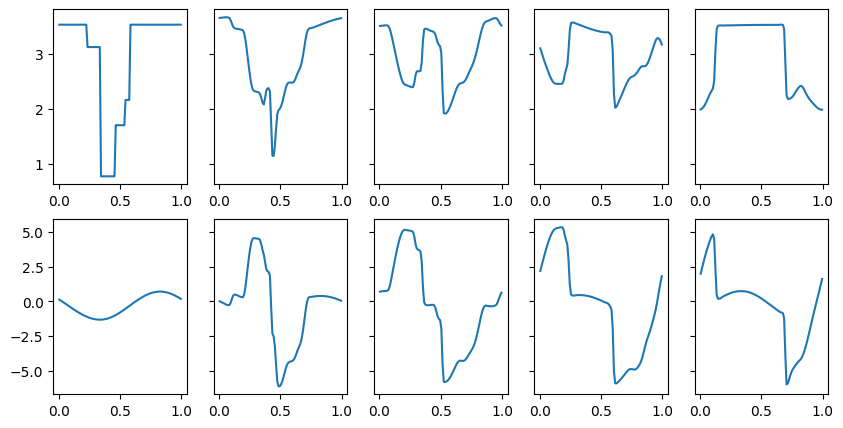

In [ ]:
import matplotlib.pyplot as plt


fig, axes = plt.subplots(2, 5, figsize=(10, 5), sharey="row")
for i in range(axes.shape[1]):
    axes[0, i].plot(dataset_test.coords["x"], dataset_test["values"][0, 4 * i, 0])
    axes[1, i].plot(dataset_test.coords["x"], dataset_test["values"][0, 4 * i, 1])

In [7]:
dt = float(dataset_test["t"][1] - dataset_test["t"][0])
dx = float(dataset_test["x"][1] - dataset_test["x"][0])
results_dict = defaultdict(list)
for model_type in (
    "DISCO",
    "DPOT",
    "HyperFluxFNOLocal",
):
    for seed in tqdm((0, 10, 20)):
        model_dir = (
            checkpoint_dir
            / "shallow_water_1d"
            / model_type
            / "OneStepLoss"
            / f"seed={seed}"
        )
        model = load_model(one(model_dir.iterdir()))
        model = eqx.nn.inference_mode(model, True)
        results = jax.lax.map(
            eqx.filter_jit(lambda u: compute_metrics(model, u, (dt, dx))),
            segments,
            batch_size=1000,
        )
        print(jax.tree.map(lambda x: x.shape, results))
        results_dict[model_type].append(jax.tree.map(jnp.mean, results))

  0%|          | 0/3 [00:00<?, ?it/s]/home/jhko725/projects/CONTEXT_FLUX_NO/.venv/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1269: UserWarning: Sharding info not provided when restoring. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(
E0506 22:26:57.027871 3171902 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0506 22:26:57.454857 3171902 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0506 22:26:58.331749 3171902 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing w

{'l2_onestep': (619752,), 'l2_rollout': (619752,), 'l_inf_onestep': (619752,), 'l_inf_rollout': (619752,)}


 67%|██████▋   | 2/3 [2:02:11<1:02:40, 3760.01s/it]

{'l2_onestep': (619752,), 'l2_rollout': (619752,), 'l_inf_onestep': (619752,), 'l_inf_rollout': (619752,)}


100%|██████████| 3/3 [2:58:51<00:00, 3577.27s/it]  


...

{'l2_onestep': (619752,), 'l2_rollout': (619752,), 'l_inf_onestep': (619752,), 'l_inf_rollout': (619752,)}


 67%|██████▋   | 2/3 [23:42<11:49, 709.22s/it]

{'l2_onestep': (619752,), 'l2_rollout': (619752,), 'l_inf_onestep': (619752,), 'l_inf_rollout': (619752,)}


100%|██████████| 3/3 [35:28<00:00, 709.43s/it]

{'l2_onestep': (619752,), 'l2_rollout': (619752,), 'l_inf_onestep': (619752,), 'l_inf_rollout': (619752,)}


In [8]:
import json


with open("../../data/analysis/shallow_water_ood_step_grf.json", "w") as f:
    json.dump(jax.tree.map(lambda x: float(x), results_dict), f)

In [9]:
for model_name, res in results_dict.items():
    res_ = jax.tree.transpose(jax.tree.structure(["*"] * 3), None, res)
    print(
        model_name,
        jax.tree.map(
            lambda list_: {
                "mean": jnp.mean(jnp.asarray(list_)),
                "std": jnp.std(jnp.asarray(list_)),
            },
            res_,
            is_leaf=lambda x: isinstance(x, list),
        ),
    )

DISCO {'l2_onestep': {'mean': Array(0.05853901, dtype=float32), 'std': Array(0.00115569, dtype=float32)}, 'l2_rollout': {'mean': Array(0.3345881, dtype=float32), 'std': Array(0.01014877, dtype=float32)}, 'l_inf_onestep': {'mean': Array(0.24559703, dtype=float32), 'std': Array(0.0042857, dtype=float32)}, 'l_inf_rollout': {'mean': Array(0.9401237, dtype=float32), 'std': Array(0.06754658, dtype=float32)}}
DPOT {'l2_onestep': {'mean': Array(0.07445969, dtype=float32), 'std': Array(0.00536103, dtype=float32)}, 'l2_rollout': {'mean': Array(0.45926425, dtype=float32), 'std': Array(0.00606772, dtype=float32)}, 'l_inf_onestep': {'mean': Array(0.3463118, dtype=float32), 'std': Array(0.02771155, dtype=float32)}, 'l_inf_rollout': {'mean': Array(0.9766633, dtype=float32), 'std': Array(0.00547094, dtype=float32)}}
HyperFluxFNOLocal {'l2_onestep': {'mean': Array(0.12540036, dtype=float32), 'std': Array(0.00282912, dtype=float32)}, 'l2_rollout': {'mean': Array(0.42773792, dtype=float32), 'std': Array(